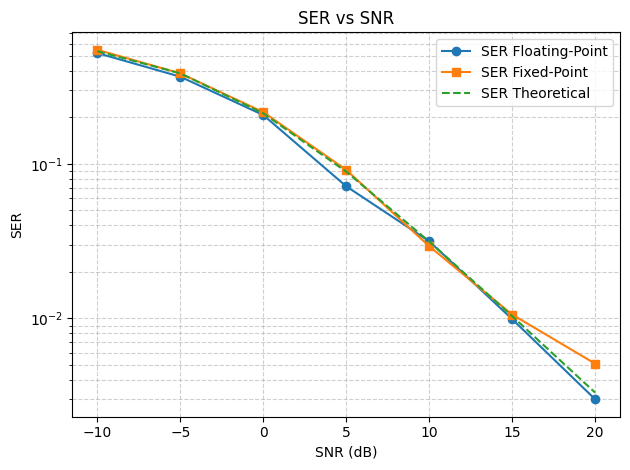

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSVs
df = pd.read_csv("ser_vs_snr.csv")
df_fp = pd.read_csv("ser_vs_snr_FP.csv")

# Extract SNR
snr_db = df["snr_db"].to_numpy()
snr_linear = 10 ** (snr_db / 10)

# Parameters for theory
L = 3
snr_eff = L * snr_linear

# Theoretical BER and SER
theory_ber = 0.5 * (1 - np.sqrt(snr_eff / (snr_eff + 2)))
theory_ser = 1 - (1 - theory_ber) ** 2   # QPSK SER from BER approximation

# ---------------- SER Plot ----------------
#plt.figure(figsize=(8, 5))
plt.semilogy(df["snr_db"], df["average_ser"], "o-", label="SER Floating-Point")
plt.semilogy(df_fp["snr_db"], df_fp["average_ser"], "s-", label="SER Fixed-Point")
plt.semilogy(snr_db, theory_ser, "--", label="SER Theoretical")

plt.xlabel("SNR (dB)")
plt.ylabel("SER")
plt.title("SER vs SNR")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


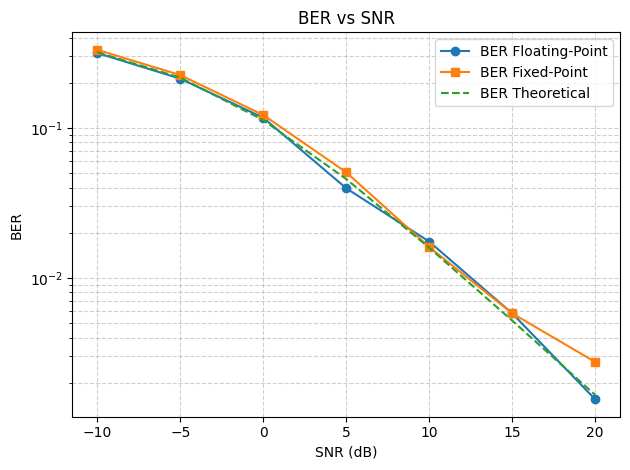

In [10]:

# ---------------- BER Plot ----------------
#plt.figure(figsize=(8, 5))
plt.semilogy(df["snr_db"], df["average_ber"], "o-", label="BER Floating-Point")
plt.semilogy(df_fp["snr_db"], df_fp["average_ber"], "s-", label="BER Fixed-Point")
plt.semilogy(snr_db, theory_ber, "--", label="BER Theoretical")

plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()